# Using the Met Office Site Archive

This notebook demonstrates how to use the PyEarthTools Met Office site archive. <br>
Place the Met Office .pyearthtoolsconfig file in your home directory so PyEarthTools can automatically detect and register datasets on disk. <br>
So far we have configured some demo data with a subset of time and variables for the following datasets:
* ERA5 low resolution (WeatherBench) data. 
* Met Office Global (2018)
* Met Office UKV (2018)

This notebook will demonstrate how to load PyEarthTools and load data from those datasets with minimal (low-code) approaches. 

In [ ]:
### Currently need to import by appending the site archive path to the system path - remove in future versions when solved. ###

import sys, os
username = os.getenv("USER")
sys.path.append(f"/home/users/{username}/Projects/PyEarthTools/packages/met_office_site_archive/src/")

## Project setup

#### Imports
If you are in the Met Office organisation you should place the `.pyearthtoolsconfig` file in your home directory as this is read during the `import site_archive_met_office` step and will be used to import the example datasets on disc for you to use. 

In [1]:
import pyearthtools
from pyearthtools import data, pipeline

import site_archive_met_office

ROOT_DIRECTORIES: {'ERA5lowres': '/data/users/infolab/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


#### Check root directories
Use the `.get_root_directories()` method to check what datasets the PyEarthTools met_office_site has registered. 

In [2]:
print(site_archive_met_office.get_root_directories())

{'ERA5lowres': '/data/users/infolab/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


#### Manually update dataset locations
You can add paths for the datasets you wish to work with manually using the `.set_root_directory` method.
* The dataset key needs to exist in the ROOT_DIRECTORIES dictionary as it will require a data accessor file.
* This is useful if you have data stored in a different location.

In [3]:
# site_archive_met_office.set_root_directory("ROOT_Key", "/path/to/data/")

# Print the updated ROOT_DIRECTORIES
print(site_archive_met_office.get_root_directories())

{'ERA5lowres': '/data/users/infolab/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


#### Parameters for this notebook

In [3]:
vmin = 220
vmax = 320
cmap = 'coolwarm'

## Working with ERA5 low resolution (WeatherBench) data
This technique can be used to quickly create a dataset object. <br>
Pass an array of the variables you wish to work with to the dataset archive.

In [4]:
era5 = pyearthtools.data.archive.ERA5lowres(['2m_temperature', 'u', 'v'])
era5

ERA5lowres
	Description                    ECWMF ReAnalysis v5
		 range                          '1970-current'
		 Documentation                  'https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

Using the dataset object index on a date of interest to select the data for that date. 

In [5]:
doi = '2015-01-01T00'  
era5_data = era5[doi]
era5_data

<xarray.Dataset> Size: 222kB
Dimensions:    (latitude: 32, longitude: 64, time: 1, level: 13)
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * time       (time) datetime64[ns] 8B 2015-01-01
  * level      (level) int32 52B 50 100 150 200 250 300 ... 600 700 850 925 1000
Data variables:
    t2m        (time, latitude, longitude) float32 8kB dask.array<chunksize=(1, 32, 64), meta=np.ndarray>
    u          (time, level, latitude, longitude) float32 106kB dask.array<chunksize=(1, 8, 19, 39), meta=np.ndarray>
    v          (time, level, latitude, longitude) float32 106kB dask.array<chunksize=(1, 8, 19, 39), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6

Let's plot the data to verify our process worked. 

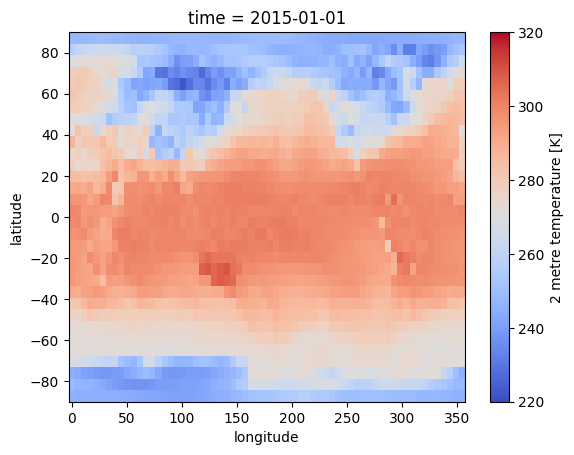

In [6]:
era5_data.t2m.plot(cmap=cmap, vmin=vmin, vmax=vmax)

## Working with Met Office UKV data
This technique can be used to quickly create a dataset object. <br>
Pass an array of the variables you wish to work with to the dataset archive.

In [7]:
moukv = pyearthtools.data.archive.MOUKV(['2m_temperature', 'u', 'v'])
moukv

MOUKV
	Description                    Met Office UKV (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/ukv_model_data_sheet_2019.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

Using the dataset object index on a date of interest to select the data for that date. 

In [17]:
doi = '2018-06-12T03'
moukv_data = moukv[doi]
moukv_data

Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_ukv/prods_op_ukv_20180612_03_000.nc')]


<xarray.Dataset> Size: 14MB
Dimensions:                      (time: 1, grid_latitude: 810,
                                  grid_longitude: 621, grid_latitude_0: 811,
                                  grid_longitude_0: 621)
Coordinates:
  * grid_latitude                (grid_latitude) float32 3kB -3.771 ... 7.151
  * grid_longitude               (grid_longitude) float64 5kB 354.9 ... 363.3
    forecast_period              timedelta64[ns] 8B ...
    forecast_reference_time      datetime64[ns] 8B ...
  * time                         (time) datetime64[ns] 8B 2018-06-12T03:00:00
    height                       float64 8B ...
    forecast_period_0            timedelta64[ns] 8B ...
    time_0                       datetime64[ns] 8B ...
  * grid_latitude_0              (grid_latitude_0) float32 3kB -3.777 ... 7.158
  * grid_longitude_0             (grid_longitude_0) float64 5kB 354.9 ... 363.3
    height_0                     float64 8B ...
Data variables:
    air_pressure_at_sea_level    (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    rotated_latitude_longitude   (time) int32 4B -2147483647
    air_temperature              (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    specific_humidity            (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    surface_altitude             (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    toa_outgoing_shortwave_flux  (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    x_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
    y_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.8
    Conventions:  CF-1.7

Let's plot the data to verify our process worked. 

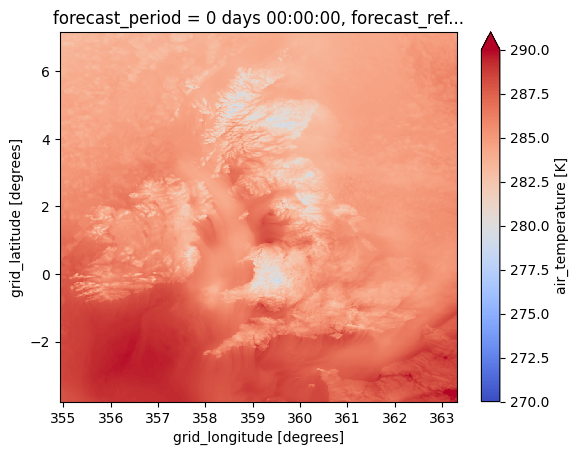

In [18]:
moukv_data.air_temperature.plot(cmap=cmap, vmin=270, vmax=290)

## Working with Met Office Global data
This technique can be used to quickly create a dataset object. <br>
Pass an array of the variables you wish to work with to the dataset archive.

In [10]:
moglobal = pyearthtools.data.archive.MOGLOBAL(['2m_temperature', 'u', 'v'])
moglobal

MOGLOBAL
	Description                    Met Office Global (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/global-nwp-asdi-datasheet.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

Using the dataset object index on a date of interest to select the data for that date. 

In [11]:
doi = '2018-09-02T00'
moglobal_data = moglobal[doi]
moglobal_data

Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180902_00_000.calc.nc')]


<xarray.Dataset> Size: 177MB
Dimensions:                    (time: 1, latitude: 1920, longitude: 2560,
                                bnds: 2, latitude_0: 1921, longitude_0: 2560)
Coordinates:
  * latitude                   (latitude) float32 8kB -89.95 -89.86 ... 89.95
  * longitude                  (longitude) float32 10kB 0.07031 0.2109 ... 359.9
    forecast_period            timedelta64[ns] 8B ...
    forecast_reference_time    datetime64[ns] 8B ...
  * time                       (time) datetime64[ns] 8B 2018-09-02
    height                     float64 8B ...
    forecast_period_0          timedelta64[ns] 8B ...
    time_0                     datetime64[ns] 8B ...
  * latitude_0                 (latitude_0) float32 8kB -90.0 -89.91 ... 90.0
  * longitude_0                (longitude_0) float32 10kB 0.0 0.1406 ... 359.9
    height_0                   float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    air_pressure_at_sea_level  (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    latitude_longitude         (time) int32 4B -2147483647
    air_temperature            (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    air_temperature_0          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    forecast_period_0_bnds     (time, bnds) float64 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_0_bnds                (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    air_temperature_1          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    land_binary_mask           (time, latitude, longitude) int32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    specific_humidity          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    surface_altitude           (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    x_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
    y_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.8
    Conventions:  CF-1.7

Let's plot the data to verify our process worked. 

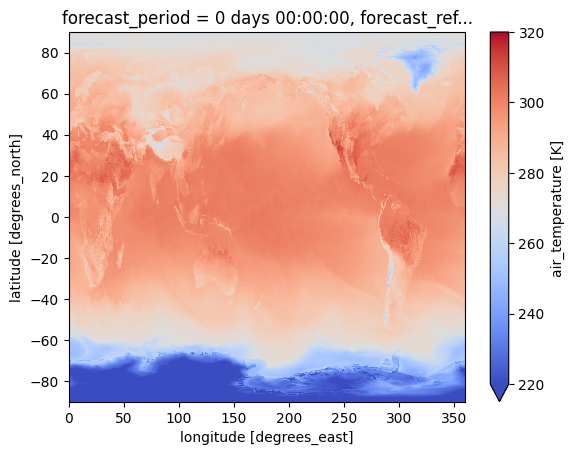

In [12]:
moglobal_data.air_temperature.plot(cmap=cmap, vmin=vmin, vmax=vmax)

Fontconfig error: Cannot load default config file: No such file: (null)


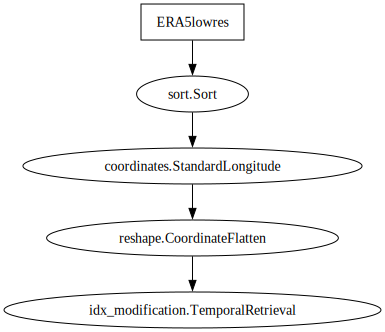

In [13]:
data_preparation = pyearthtools.pipeline.Pipeline(
    
    pyearthtools.data.archive.ERA5lowres(["2m_temperature", "u", "v", "geopotential", "vorticity"]),    # Select data
    pyearthtools.pipeline.operations.xarray.Sort(["t2", "u", "v", "vorticity", "geopotential"]),        # Sort the data
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),                           # Convert coordinates to 0-360 longitude        
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),                         # Flatten the level coordinate    
    
    pyearthtools.pipeline.modifications.TemporalRetrieval(concat=True, samples=((-1, 1), (6, 1))),      # Retrieve previous/next samples, dt = 1H
    
)

# Display the pipeline
data_preparation

In [14]:
doi = '2015-01-01T00'  
input_and_target_samples = data_preparation[doi]

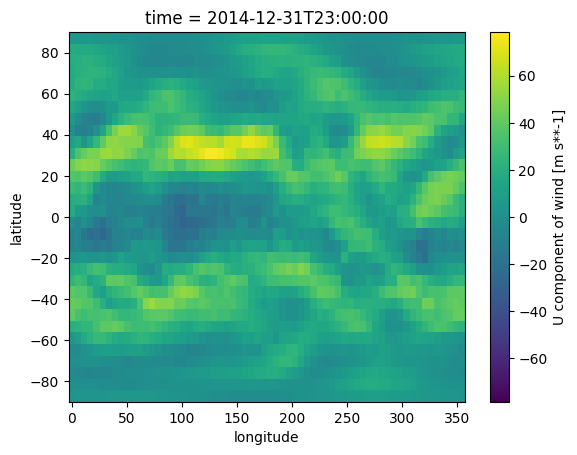

In [15]:
input_and_target_samples[0].u150.plot(cmap='viridis')

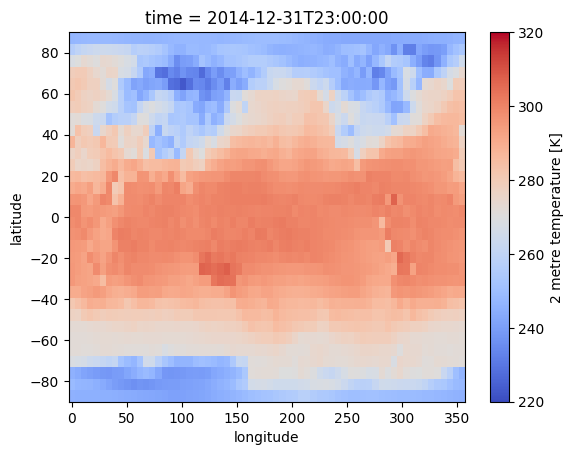

In [16]:
temperature = getattr(input_and_target_samples[0], 't2m')
temperature.plot(cmap=cmap, vmin=vmin, vmax=vmax)